# Farm use case LLM scalability

In [1]:
%cd ..

C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation


C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
%pwd  # should be "llm-adaptation"

'C:\\Users\\micha\\OneDrive - Univerzita Karlova\\research\\2024-LLM-DEECo\\llm-adaptation'

## Run the experiment

In [3]:
import subprocess

def run(llm_config, scale_config):
    # configs = ["farm/configs/default.yaml", "farm/configs/config_no_battery.yaml", "farm/configs/scalability/scale.yaml", "configs/jinja.yaml", "DSL/drones.yaml", f"configs/{llm_config}.yaml", "farm/configs/no_battery_llm.yaml", "farm/configs/simulation_description_2.yaml", "farm/configs/strategy_multiple.yaml", "configs/retry2.yaml", f"farm/configs/scalability/{scale_config}.yaml"]
    configs = ["farm/configs/default.yaml", "farm/configs/config_no_battery.yaml", "farm/configs/scalability/scale.yaml", "configs/jinja.yaml", "DSL/drones.yaml", f"configs/{llm_config}.yaml", "farm/configs/no_battery_llm.yaml", "farm/configs/simulation_description_2.yaml", "configs/retry2.yaml", f"farm/configs/scalability/{scale_config}.yaml"]  # without strategy
    run = ["python", "main.py", *configs, "-e", "1", "-s", "1"]
    # run += ["--extra_config", "{\"steps\": 30}"]

    return " ".join(run)

    # result = subprocess.run(run, capture_output=False)
    result = subprocess.run(run, capture_output=True)
    stdout = result.stdout.decode("utf-8")
    print(stdout.partition("Simulation done")[2])

    stderr = result.stderr.decode("utf-8")
    if (stderr):
        print(stderr)

### GPT-4o mini

In [4]:
run("llm_gpt4omini", "scale1")

'python main.py farm/configs/default.yaml farm/configs/config_no_battery.yaml farm/configs/scalability/scale.yaml configs/jinja.yaml DSL/drones.yaml configs/llm_gpt4omini.yaml farm/configs/no_battery_llm.yaml farm/configs/simulation_description_2.yaml configs/retry2.yaml farm/configs/scalability/scale1.yaml -e 1 -s 1'

### o3-mini

In [5]:
run("llm_o3mini", "scale1")

'python main.py farm/configs/default.yaml farm/configs/config_no_battery.yaml farm/configs/scalability/scale.yaml configs/jinja.yaml DSL/drones.yaml configs/llm_o3mini.yaml farm/configs/no_battery_llm.yaml farm/configs/simulation_description_2.yaml configs/retry2.yaml farm/configs/scalability/scale1.yaml -e 1 -s 1'

In [6]:
run("llm_o3mini", "scale17")

'python main.py farm/configs/default.yaml farm/configs/config_no_battery.yaml farm/configs/scalability/scale.yaml configs/jinja.yaml DSL/drones.yaml configs/llm_o3mini.yaml farm/configs/no_battery_llm.yaml farm/configs/simulation_description_2.yaml configs/retry2.yaml farm/configs/scalability/scale17.yaml -e 1 -s 1'

In [7]:
run("llm_o3mini", "scale35")

'python main.py farm/configs/default.yaml farm/configs/config_no_battery.yaml farm/configs/scalability/scale.yaml configs/jinja.yaml DSL/drones.yaml configs/llm_o3mini.yaml farm/configs/no_battery_llm.yaml farm/configs/simulation_description_2.yaml configs/retry2.yaml farm/configs/scalability/scale35.yaml -e 1 -s 1'

## Results

In [8]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.set_theme()

In [9]:
results_folder = Path("./logs/no_battery/scale")

In [10]:
results_files = sorted(results_folder.glob("*/*.llm.csv"))
print(len(results_files), "files found")

10 files found


In [47]:
datas = []

In [48]:
for file in results_files:
    try:
        name = file.stem
        if "jinja_" not in name:
            continue

        data = pd.read_csv(file)
        stats_file = file.parent / name.replace(".llm", ".csv")
        stats = pd.read_csv(stats_file)
        damage = stats.iloc[299]["damage"]

        parts = name.split("_")
        llm = parts[1]
        scale = parts[-1].split(".")[0]
        params = parts[2:-1]
        params = ",\n".join(params)

        # data["llm"] = llm
        data["llm"] = llm + "_" + ("high" if "strategy" in params else "zero")
        data["scale"] = scale
        data["params"] = params
        data["damage"] = damage

        # counts of drones in state
        steps = stats[stats["step"].isin(data["step"])]
        data["protecting"] = np.nan
        data["idle"] = np.nan
        data["moving_to_field"] = np.nan
        mask = data["try"] == 0
        data.loc[mask, "protecting"] = steps["PROTECTING"].values
        data.loc[mask, "idle"] = steps["IDLE"].values
        data.loc[mask, "moving_to_field"] = steps["MOVING_TO_FIELD"].values

        datas.append(data)

    except pd.errors.EmptyDataError:
        print("Skipping empty file", file)
    except IndexError:
        print("Index error in file", file)

C:\Users\micha\AppData\Local\Temp\ipykernel_28828\2433622315.py:9: DtypeWarning: Columns (10,55,58,70,85,88,112,127,148,157,199,238,241,247,268,271,283,289,322,361,373,526,529,532,535,538,541,544,547,550,568,571,574,733,763,883,1012,1132,1183,1318,1348,1948,2248) have mixed types. Specify dtype option on import or set low_memory=False.
  stats = pd.read_csv(stats_file)
C:\Users\micha\AppData\Local\Temp\ipykernel_28828\2433622315.py:9: DtypeWarning: Columns (37,40,43,52,55,58,61,79,82,157,160,163,250,253,298,577,655) have mixed types. Specify dtype option on import or set low_memory=False.
  stats = pd.read_csv(stats_file)
C:\Users\micha\AppData\Local\Temp\ipykernel_28828\2433622315.py:9: DtypeWarning: Columns (10,13,16,19,22,25,28,31,34,37,40,43,46,49,52,55,58,61,64,67,70,145,148,151,154,157,160,163,166,169,172,175,178,181,184,187,190,193,196,199,202,205,208,211,214,217,220,223,226,229,232,235,238,241,244,247,250,253,256,259,262,265,268,271,274,277,280,283,286,289,292,295,298,301,304,3

In [50]:
summary = pd.concat(datas, ignore_index=True)
summary

,step,try,errors,input_tokens,output_tokens,reasoning_tokens,response_time,llm,scale,params,damage,protecting,idle,moving_to_field
0,1,0,0,1157,678,0,10.432185,gpt4omini_zero,scale1,"sd2,\nretry2",328,1.0,2.0,5.0
1,11,0,0,1211,681,0,9.855652,gpt4omini_zero,scale1,"sd2,\nretry2",328,6.0,0.0,2.0
2,21,0,0,1231,886,0,11.426983,gpt4omini_zero,scale1,"sd2,\nretry2",328,7.0,0.0,1.0
3,31,0,0,1229,827,0,12.592225,gpt4omini_zero,scale1,"sd2,\nretry2",328,5.0,0.0,3.0
4,41,0,0,1235,724,0,12.007943,gpt4omini_zero,scale1,"sd2,\nretry2",328,5.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,251,1,0,52416,6403,2112,52.587189,o3mini_high,scale90,"sd2,\nstrategyMultiple,\nretry2",7784,NaN,NaN,NaN
370,261,0,0,47824,6879,2624,50.481284,o3mini_high,scale90,"sd2,\nstrategyMultiple,\nretry2",7784,0.0,688.0,12.0
371,271,0,0,47848,6943,2688,48.294579,o3mini_high,scale90,"sd2,\nstrategyMultiple,\nretry2",7784,0.0,688.0,12.0
372,281,0,0,48054,5791,1536,47.294544,o3mini_high,scale90,"sd2,\nstrategyMultiple,\nretry2",7784,1.0,688.0,11.0


In [51]:
summary['original_scale'] = summary['scale'].apply(lambda s: int(s.split("scale")[-1]))
summary['scale'] = summary['scale'].map({
    # gpt4omini
    "scale1": 1,
    "scale10": 5,
    "scale20": 10,
    "scale57": 25,
    "scale116": 50,
    "scale206": 90,
    # o3mini
    "scale17": 5,
    "scale35": 10,
    "scale90": 25,
    "scale180": 50,
    "scale323": 90,
})

In [52]:
summary.to_csv(results_folder / "summary.csv", index=False)

In [53]:
initial = summary[summary["try"] == 0].copy()
initial

,step,try,errors,input_tokens,output_tokens,reasoning_tokens,response_time,llm,scale,params,damage,protecting,idle,moving_to_field,original_scale
0,1,0,0,1157,678,0,10.432185,gpt4omini_zero,1,"sd2,\nretry2",328,1.0,2.0,5.0,1
1,11,0,0,1211,681,0,9.855652,gpt4omini_zero,1,"sd2,\nretry2",328,6.0,0.0,2.0,1
2,21,0,0,1231,886,0,11.426983,gpt4omini_zero,1,"sd2,\nretry2",328,7.0,0.0,1.0,1
3,31,0,0,1229,827,0,12.592225,gpt4omini_zero,1,"sd2,\nretry2",328,5.0,0.0,3.0,1
4,41,0,0,1235,724,0,12.007943,gpt4omini_zero,1,"sd2,\nretry2",328,5.0,0.0,3.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,251,0,1,47817,8489,3968,60.096638,o3mini_high,25,"sd2,\nstrategyMultiple,\nretry2",7784,0.0,676.0,24.0,90
370,261,0,0,47824,6879,2624,50.481284,o3mini_high,25,"sd2,\nstrategyMultiple,\nretry2",7784,0.0,688.0,12.0,90
371,271,0,0,47848,6943,2688,48.294579,o3mini_high,25,"sd2,\nstrategyMultiple,\nretry2",7784,0.0,688.0,12.0,90
372,281,0,0,48054,5791,1536,47.294544,o3mini_high,25,"sd2,\nstrategyMultiple,\nretry2",7784,1.0,688.0,11.0,90


### Errors

In [54]:
repeated = pd.DataFrame(columns=["llm", "scale", "try", "error_count"])
for llm in summary["llm"].unique():
    for scale in summary["scale"].unique():
        for retry in (1, 2):
            count = len(summary[(summary["llm"] == llm) & (summary["scale"] == scale) & (summary["try"] == retry)])
            repeated.loc[len(repeated)] = [llm, scale, retry, count]
repeated["error_rate"] = repeated["error_count"] / 30.0
repeated

,llm,scale,try,error_count,error_rate
0,gpt4omini_zero,1,1,0,0.000000
1,gpt4omini_zero,1,2,0,0.000000
2,gpt4omini_zero,5,1,0,0.000000
3,gpt4omini_zero,5,2,0,0.000000
4,gpt4omini_zero,50,1,0,0.000000
5,gpt4omini_zero,50,2,0,0.000000
6,gpt4omini_zero,10,1,0,0.000000
7,gpt4omini_zero,10,2,0,0.000000
8,gpt4omini_zero,25,1,0,0.000000
9,gpt4omini_zero,25,2,0,0.000000


In [55]:
repeated[repeated["try"] == 1]

,llm,scale,try,error_count,error_rate
0,gpt4omini_zero,1,1,0,0.000000
2,gpt4omini_zero,5,1,0,0.000000
4,gpt4omini_zero,50,1,0,0.000000
6,gpt4omini_zero,10,1,0,0.000000
8,gpt4omini_zero,25,1,0,0.000000
10,gpt4omini_high,1,1,0,0.000000
12,gpt4omini_high,5,1,2,0.066667
14,gpt4omini_high,50,1,21,0.700000
16,gpt4omini_high,10,1,6,0.200000
18,gpt4omini_high,25,1,14,0.466667


In [56]:
print("Retry rate")
for _, row in repeated[repeated["try"] == 1].iterrows():
    print(f"{row['llm']}, {row['scale']}: {row['error_rate']:.1%}")

Retry rate
gpt4omini_zero, 1: 0.0%
gpt4omini_zero, 5: 0.0%
gpt4omini_zero, 50: 0.0%
gpt4omini_zero, 10: 0.0%
gpt4omini_zero, 25: 0.0%
gpt4omini_high, 1: 0.0%
gpt4omini_high, 5: 6.7%
gpt4omini_high, 50: 70.0%
gpt4omini_high, 10: 20.0%
gpt4omini_high, 25: 46.7%
o3mini_high, 1: 0.0%
o3mini_high, 5: 3.3%
o3mini_high, 50: 0.0%
o3mini_high, 10: 3.3%
o3mini_high, 25: 20.0%


In [57]:
print("Second retry rate")
for _, row in repeated[repeated["try"] == 2].iterrows():
    print(f"{row['llm']}, {row['scale']}: {row['error_rate']:.1%}")

Second retry rate
gpt4omini_zero, 1: 0.0%
gpt4omini_zero, 5: 0.0%
gpt4omini_zero, 50: 0.0%
gpt4omini_zero, 10: 0.0%
gpt4omini_zero, 25: 0.0%
gpt4omini_high, 1: 0.0%
gpt4omini_high, 5: 3.3%
gpt4omini_high, 50: 56.7%
gpt4omini_high, 10: 3.3%
gpt4omini_high, 25: 13.3%
o3mini_high, 1: 0.0%
o3mini_high, 5: 0.0%
o3mini_high, 50: 0.0%
o3mini_high, 10: 0.0%
o3mini_high, 25: 0.0%


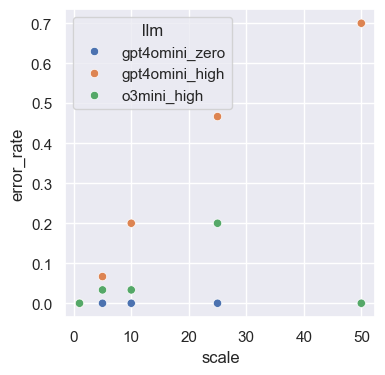

In [58]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.scatterplot(x="scale", y="error_rate", hue="llm", data=repeated[repeated["try"] == 1], ax=ax, palette="deep")
plt.show()

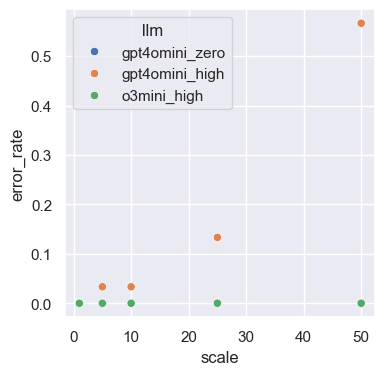

In [59]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.scatterplot(x="scale", y="error_rate", hue="llm", data=repeated[repeated["try"] == 2], ax=ax, palette="deep")
plt.show()

### Time

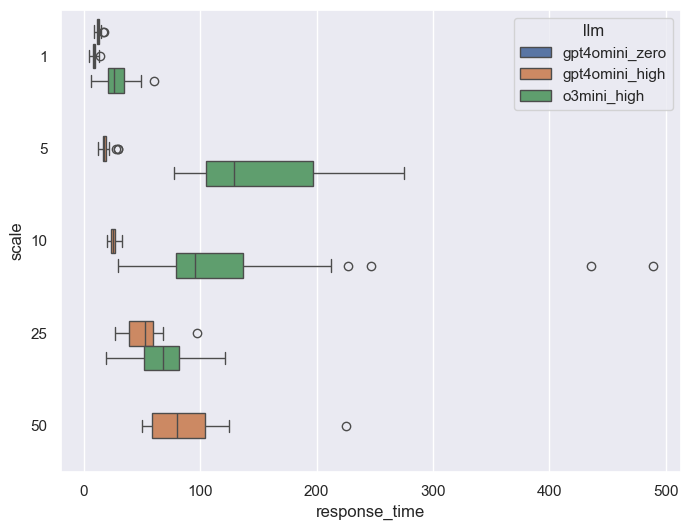

In [60]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="response_time", y="scale", hue="llm", data=initial, ax=ax, orient="h")
plt.show()

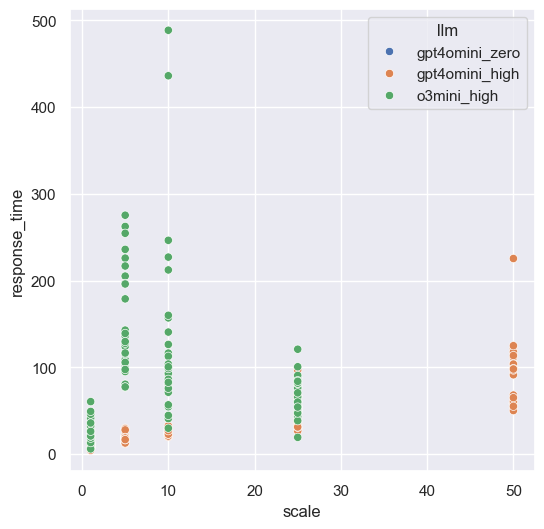

In [61]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="scale", y="response_time", hue="llm", data=initial, ax=ax, palette="deep")
plt.show()

### Input tokens

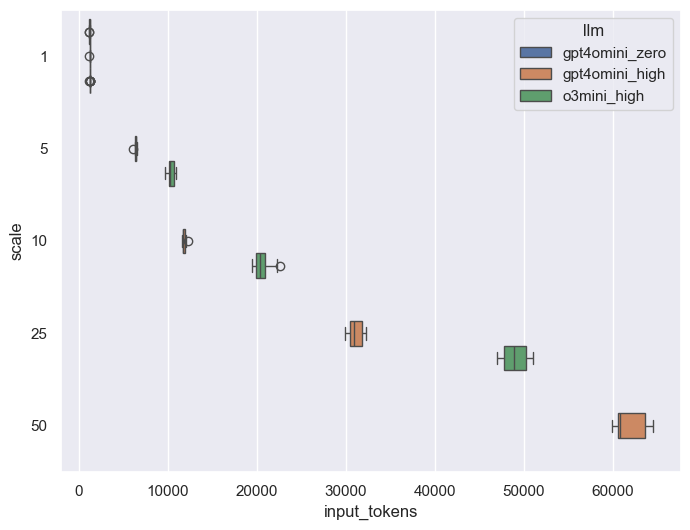

In [62]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="input_tokens", y="scale", hue="llm", data=initial, ax=ax, orient="h")
plt.show()

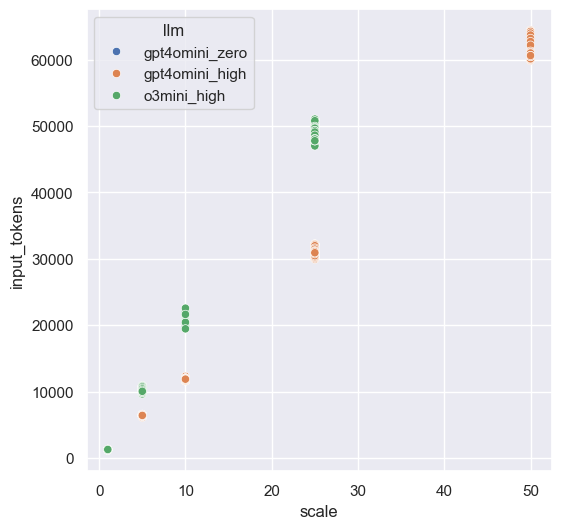

In [63]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="scale", y="input_tokens", hue="llm", data=initial, ax=ax, palette="deep")
plt.show()

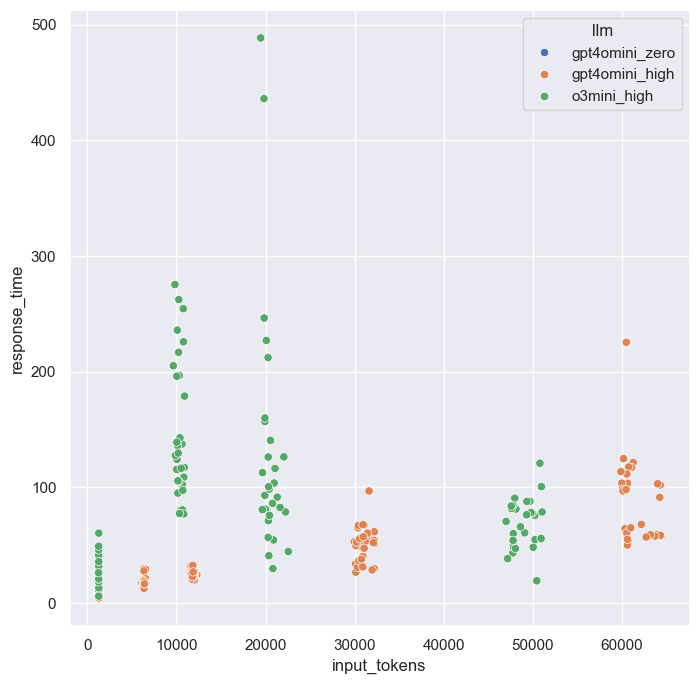

In [64]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x="input_tokens", y="response_time", hue="llm", data=initial, ax=ax, palette="deep")
plt.show()

### Output tokens

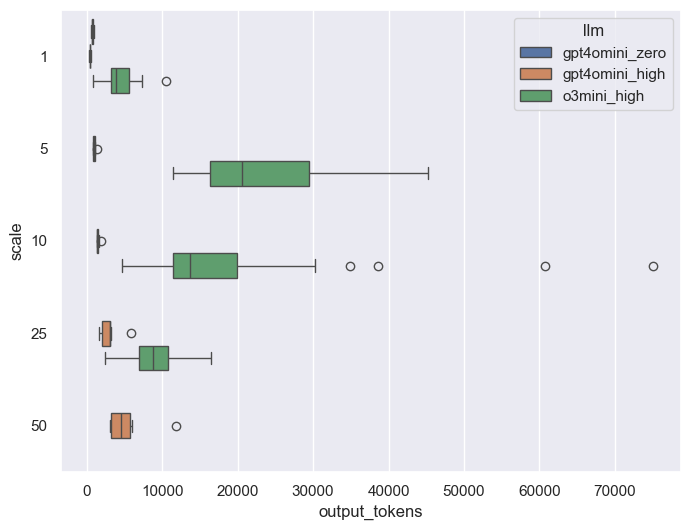

In [65]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="output_tokens", y="scale", hue="llm", data=initial, ax=ax, orient="h")
plt.show()

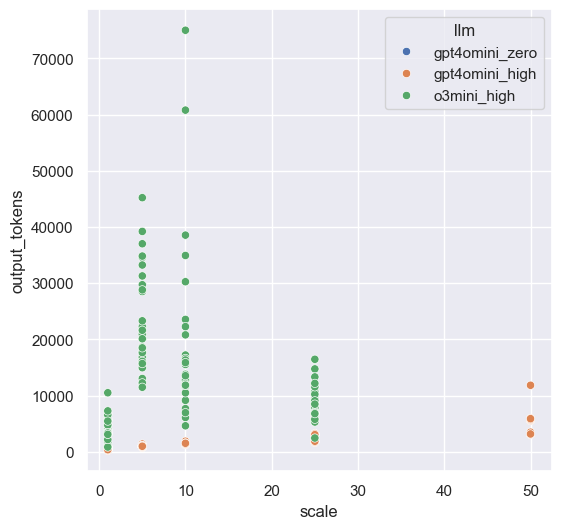

In [66]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="scale", y="output_tokens", hue="llm", data=initial, ax=ax, palette="deep")
plt.show()

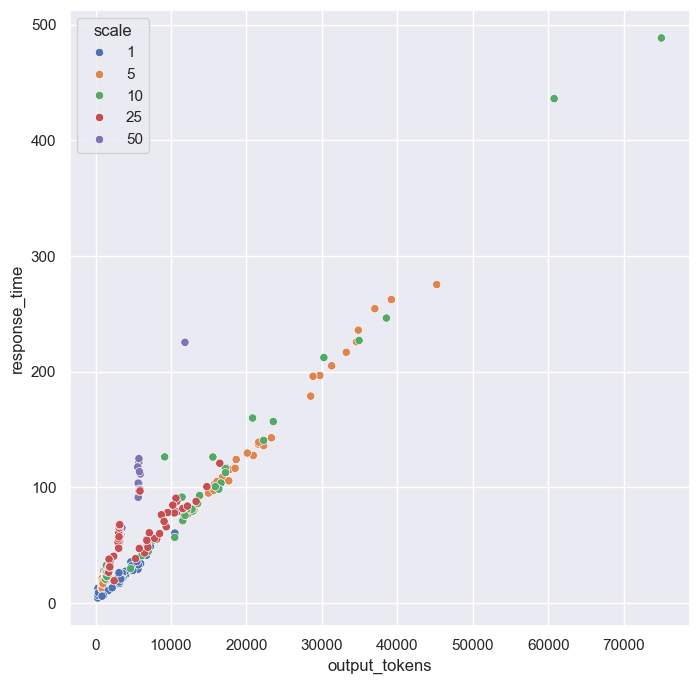

In [67]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x="output_tokens", y="response_time", hue="scale", data=initial, ax=ax, palette="deep")
plt.show()

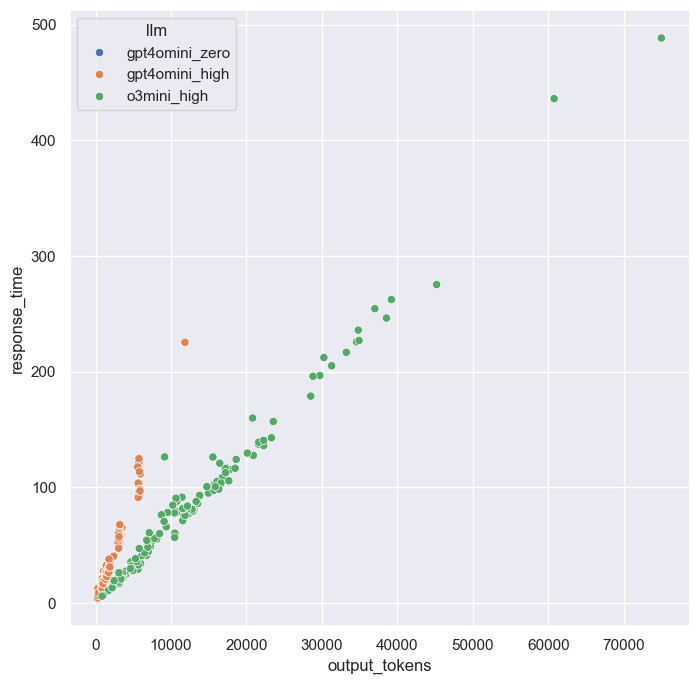

In [68]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x="output_tokens", y="response_time", hue="llm", data=initial, ax=ax, palette="deep")
plt.show()

### Drone states

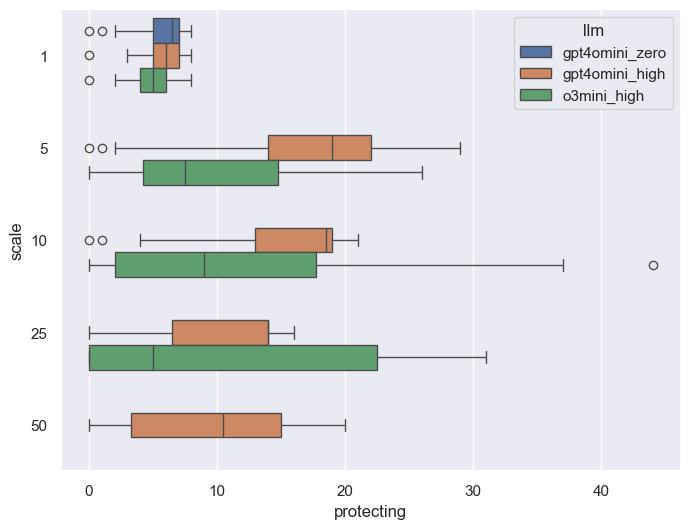

In [69]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="protecting", y="scale", hue="llm", data=initial, ax=ax, orient="h")
plt.show()

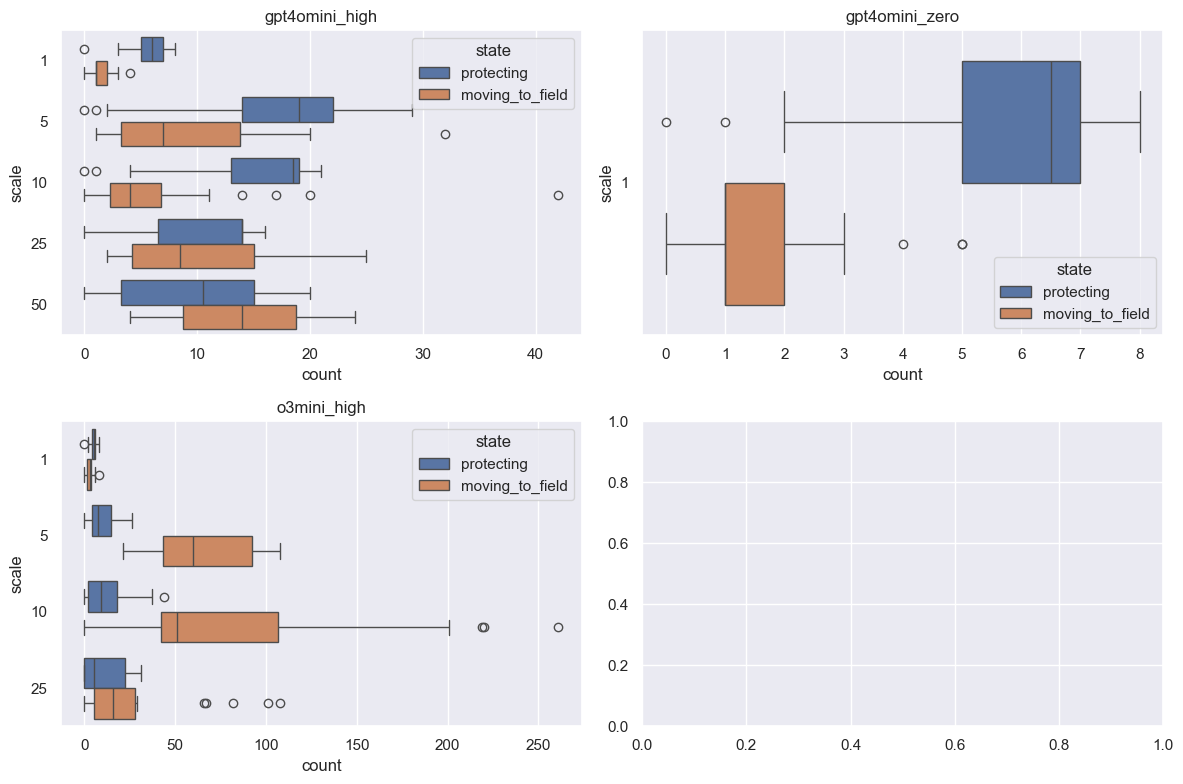

In [84]:
melted = pd.melt(
    initial,
    id_vars=["scale", "llm"],
    value_vars=["protecting", "moving_to_field"],
    var_name="state",
    value_name="count"
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (llm, group) in zip(axes.flatten(), melted.groupby("llm")):
    sns.boxplot(x="count", y="scale", hue="state", data=group, orient="h", ax=ax)
    ax.set_title(llm)
plt.tight_layout()
plt.show()

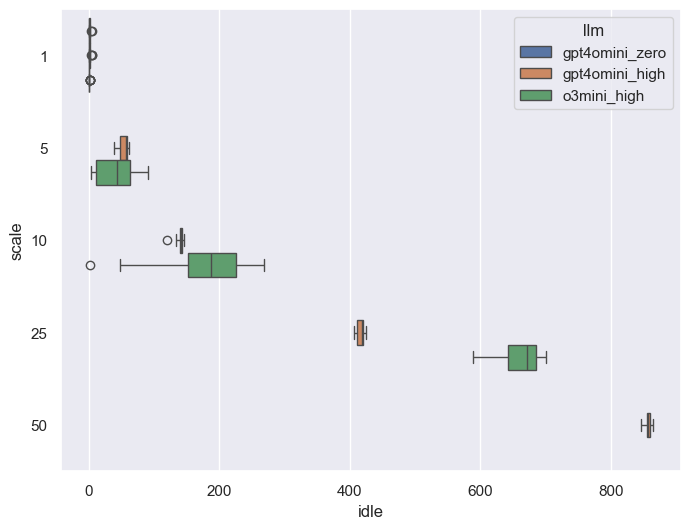

In [72]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="idle", y="scale", hue="llm", data=initial, ax=ax, orient="h")
plt.show()

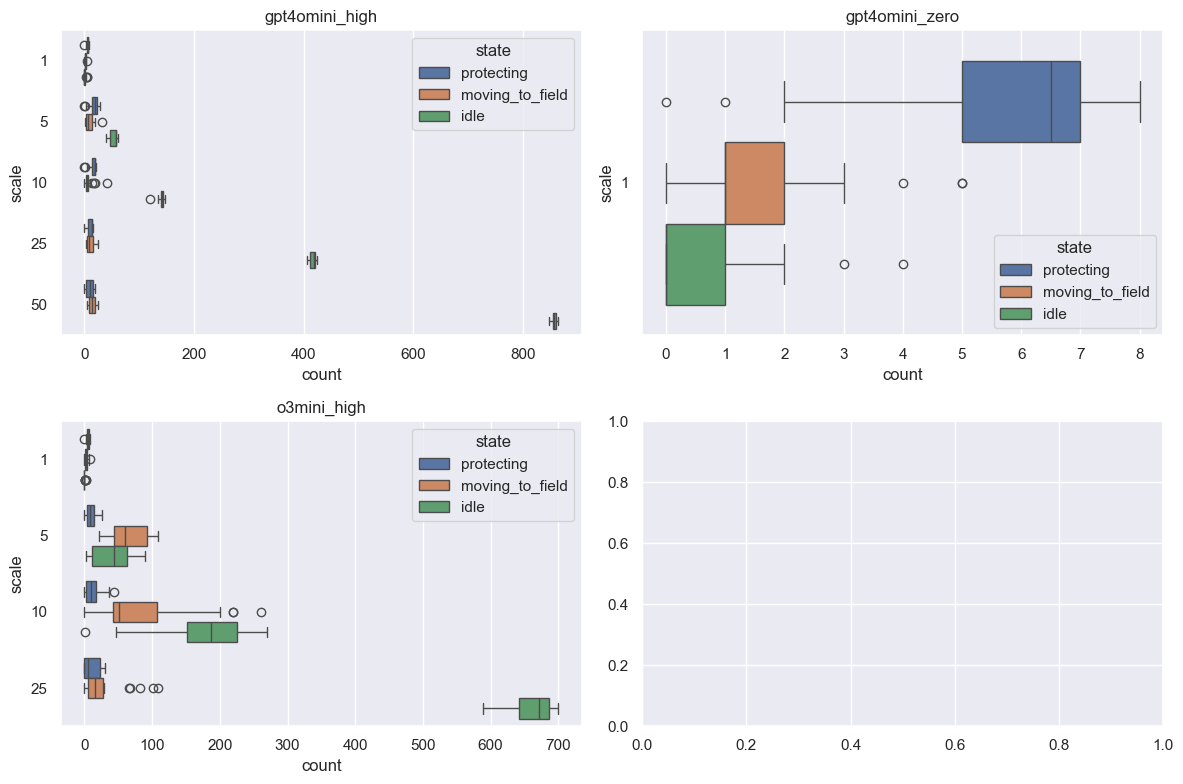

In [85]:
melted = pd.melt(
    initial,
    id_vars=["scale", "llm"],
    value_vars=["protecting", "moving_to_field", "idle"],
    var_name="state",
    value_name="count"
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (llm, group) in zip(axes.flatten(), melted.groupby("llm")):
    sns.boxplot(x="count", y="scale", hue="state", data=group, orient="h", ax=ax)
    ax.set_title(llm)
plt.tight_layout()
plt.show()

In [75]:
states = initial.groupby(["llm", "scale"]).agg({"idle": "mean", "protecting": "mean", "moving_to_field": "mean"}).reset_index()
states

,llm,scale,idle,protecting,moving_to_field
0,gpt4omini_high,1,0.833333,5.700000,1.466667
1,gpt4omini_high,5,53.433333,16.600000,8.966667
2,gpt4omini_high,10,140.500000,15.300000,6.200000
3,gpt4omini_high,25,415.833333,10.266667,10.900000
4,gpt4omini_high,50,857.600000,9.433333,13.966667
5,gpt4omini_zero,1,0.533333,5.900000,1.566667
6,o3mini_high,1,0.266667,5.133333,2.600000
7,o3mini_high,5,40.466667,9.400000,67.133333
8,o3mini_high,10,178.133333,11.900000,78.966667
9,o3mini_high,25,664.133333,10.900000,24.966667


In [76]:
for _, row in states.iterrows():
    print(f"{row['llm']}, {row['scale']}: {row['protecting'] + row['moving_to_field']:.1f}")

gpt4omini_high, 1: 7.2
gpt4omini_high, 5: 25.6
gpt4omini_high, 10: 21.5
gpt4omini_high, 25: 21.2
gpt4omini_high, 50: 23.4
gpt4omini_zero, 1: 7.5
o3mini_high, 1: 7.7
o3mini_high, 5: 76.5
o3mini_high, 10: 90.9
o3mini_high, 25: 35.9


### Damage

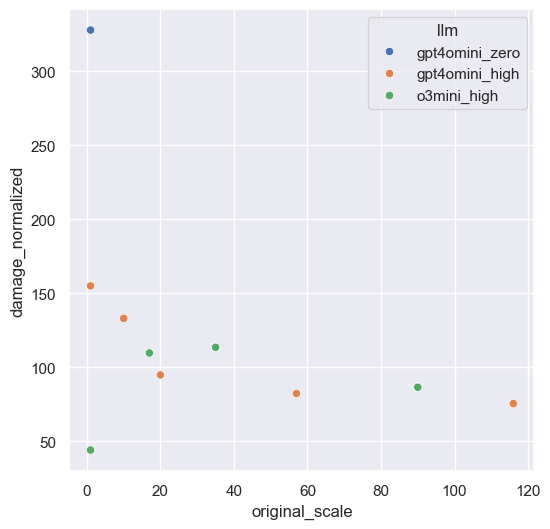

In [77]:
initial.loc[:,"damage_normalized"] = (initial["damage"] / initial["original_scale"])
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="original_scale", y="damage_normalized", hue="llm", data=initial, ax=ax, palette="deep")
plt.show()

### Cost

In [78]:
initial.loc[:,"output_only_tokens"] = initial["output_tokens"] - initial["reasoning_tokens"]

In [79]:
averages = initial.groupby(["llm", "scale"]).agg({"input_tokens": "mean", "output_only_tokens": "mean", "reasoning_tokens": "mean", "response_time": "mean"}).reset_index()
averages

,llm,scale,input_tokens,output_only_tokens,reasoning_tokens,response_time
0,gpt4omini_high,1,1274.966667,424.700000,0.000000,8.975744
1,gpt4omini_high,5,6400.100000,964.433333,0.000000,18.325013
2,gpt4omini_high,10,11804.966667,1449.733333,0.000000,25.273116
3,gpt4omini_high,25,31073.933333,2828.466667,0.000000,50.817700
4,gpt4omini_high,50,61730.033333,4693.000000,0.000000,87.192365
5,gpt4omini_zero,1,1219.666667,750.500000,0.000000,12.214472
6,o3mini_high,1,1269.533333,233.866667,4128.000000,27.678288
7,o3mini_high,5,10359.033333,951.033333,22060.800000,148.877523
8,o3mini_high,10,20538.400000,1999.000000,17111.466667,130.072166
9,o3mini_high,25,48994.266667,4232.400000,4800.000000,67.720284


In [86]:
prices = {
    "gpt4omini": { "input": 0.15 / 1_000_000, "output": 0.6 / 1_000_000, "reasoning": 0 },
    "o3mini": { "input": 1.1 / 1_000_000, "output": 4.4 / 1_000_000, "reasoning": 4.4 / 1_000_000 },
}
for llm in initial["llm"].unique():
    if llm in prices: continue
    llm_only = llm.split("_")[0]
    prices[llm] = prices[llm_only]

In [87]:
averages["input_cost"] = averages["input_tokens"] * averages["llm"].map(lambda llm: prices[llm]["input"])
averages["output_cost"] = averages["output_only_tokens"] * averages["llm"].map(lambda llm: prices[llm]["output"])
averages["reasoning_cost"] = averages["reasoning_tokens"] * averages["llm"].map(lambda llm: prices[llm]["reasoning"])

In [88]:
averages

,llm,scale,input_tokens,output_only_tokens,reasoning_tokens,response_time,input_cost,output_cost,reasoning_cost
0,gpt4omini_high,1,1274.966667,424.700000,0.000000,8.975744,0.000191,0.000255,0.000000
1,gpt4omini_high,5,6400.100000,964.433333,0.000000,18.325013,0.000960,0.000579,0.000000
2,gpt4omini_high,10,11804.966667,1449.733333,0.000000,25.273116,0.001771,0.000870,0.000000
3,gpt4omini_high,25,31073.933333,2828.466667,0.000000,50.817700,0.004661,0.001697,0.000000
4,gpt4omini_high,50,61730.033333,4693.000000,0.000000,87.192365,0.009260,0.002816,0.000000
5,gpt4omini_zero,1,1219.666667,750.500000,0.000000,12.214472,0.000183,0.000450,0.000000
6,o3mini_high,1,1269.533333,233.866667,4128.000000,27.678288,0.001396,0.001029,0.018163
7,o3mini_high,5,10359.033333,951.033333,22060.800000,148.877523,0.011395,0.004185,0.097068
8,o3mini_high,10,20538.400000,1999.000000,17111.466667,130.072166,0.022592,0.008796,0.075290
9,o3mini_high,25,48994.266667,4232.400000,4800.000000,67.720284,0.053894,0.018623,0.021120


In [89]:
for _, row in averages.iterrows():
    print(f"{row['llm']}, {row['scale']}: {row['input_cost']:.4f} + {row['output_cost']:.4f} + {row['reasoning_cost']:.4f}")

gpt4omini_high, 1: 0.0002 + 0.0003 + 0.0000
gpt4omini_high, 5: 0.0010 + 0.0006 + 0.0000
gpt4omini_high, 10: 0.0018 + 0.0009 + 0.0000
gpt4omini_high, 25: 0.0047 + 0.0017 + 0.0000
gpt4omini_high, 50: 0.0093 + 0.0028 + 0.0000
gpt4omini_zero, 1: 0.0002 + 0.0005 + 0.0000
o3mini_high, 1: 0.0014 + 0.0010 + 0.0182
o3mini_high, 5: 0.0114 + 0.0042 + 0.0971
o3mini_high, 10: 0.0226 + 0.0088 + 0.0753
o3mini_high, 25: 0.0539 + 0.0186 + 0.0211


In [90]:
totals = initial.groupby(["llm", "scale"]).agg({"input_tokens": "sum", "output_only_tokens": "sum", "reasoning_tokens": "sum", "response_time": "mean"}).reset_index()
totals["input_cost"] = totals["input_tokens"] * totals["llm"].map(lambda llm: prices[llm]["input"])
totals["output_cost"] = totals["output_only_tokens"] * totals["llm"].map(lambda llm: prices[llm]["output"])
totals["reasoning_cost"] = totals["reasoning_tokens"] * totals["llm"].map(lambda llm: prices[llm]["reasoning"])
for _, row in totals.iterrows():
    print(f"{row['llm']}, {row['scale']}: {row['input_cost'] + row['output_cost'] + row['reasoning_cost']:.2f}")

gpt4omini_high, 1: 0.01
gpt4omini_high, 5: 0.05
gpt4omini_high, 10: 0.08
gpt4omini_high, 25: 0.19
gpt4omini_high, 50: 0.36
gpt4omini_zero, 1: 0.02
o3mini_high, 1: 0.62
o3mini_high, 5: 3.38
o3mini_high, 10: 3.20
o3mini_high, 25: 2.81


In [91]:
for _, row in averages.iterrows():
    print(f"{row['llm']}, {row['scale']}: {row['response_time']:.1f}")

gpt4omini_high, 1: 9.0
gpt4omini_high, 5: 18.3
gpt4omini_high, 10: 25.3
gpt4omini_high, 25: 50.8
gpt4omini_high, 50: 87.2
gpt4omini_zero, 1: 12.2
o3mini_high, 1: 27.7
o3mini_high, 5: 148.9
o3mini_high, 10: 130.1
o3mini_high, 25: 67.7


### CoT tokens

In [92]:
import tiktoken
encoding = tiktoken.encoding_for_model("gpt-4")

In [93]:
answer = len(encoding.encode("<answer>\n</answer>"))
answer

6

In [94]:
protecting = len(encoding.encode("Drone_123: protecting Field_456"))
protecting

9

In [95]:
idle = len(encoding.encode("Drone_123: idle"))
idle

6

In [96]:
initial.loc[:,"answer_tokens"] = answer + (initial["protecting"] + initial["moving_to_field"]) * protecting + initial["idle"] * idle

In [97]:
initial[["llm", "errors", "answer_tokens", "output_only_tokens", "output_tokens"]]

,llm,errors,answer_tokens,output_only_tokens,output_tokens
0,gpt4omini_zero,0,72.0,678,678
1,gpt4omini_zero,0,78.0,681,681
2,gpt4omini_zero,0,78.0,886,886
3,gpt4omini_zero,0,78.0,827,827
4,gpt4omini_zero,0,78.0,724,724
...,...,...,...,...,...
368,o3mini_high,1,4278.0,4521,8489
370,o3mini_high,0,4242.0,4255,6879
371,o3mini_high,0,4242.0,4255,6943
372,o3mini_high,0,4242.0,4255,5791


In [98]:
initial.loc[:,"cot_tokens"] = initial["output_tokens"] - initial["answer_tokens"]
no_errors = initial[initial["errors"] == 0]
for _, row in no_errors.groupby(["llm", "scale"]).agg({"cot_tokens": "mean"}).reset_index().iterrows():
    print(f"{row['llm']}, {row['scale']}: {row['cot_tokens']:.0f}")

gpt4omini_high, 1: 349
gpt4omini_high, 5: 405
gpt4omini_high, 10: 389
gpt4omini_high, 25: 584
gpt4omini_high, 50: 383
gpt4omini_zero, 1: 674
o3mini_high, 1: 4285
o3mini_high, 5: 21312
o3mini_high, 10: 17478
o3mini_high, 25: 4705
